<a href="https://colab.research.google.com/github/Tonstonte/credit-scoring-xai-project_uniabj/blob/main/ROHAN_PARIS_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# XGBOOST

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [ ]:
!pip install shap
!pip install lime
import shap
import lime
from sklearn.linear_model import LogisticRegression

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0b0416f6c0e7ffe7b0b59ccebea7806da29fec58745af7c16bb75e637cb14a43
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
df = pd.read_csv("/content/train.csv")
df.head(15)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


In [ ]:
drop_cols = ["ID", "Name", "SSN", "Month"]
df.drop(columns=drop_cols, inplace=True)

In [ ]:
def clean_numeric_str(series):
    return (
        series.astype(str)
              .str.replace(r"[^0-9.\-]", "", regex=True)
              .replace("", np.nan)
              .astype(float)
    )

str_numeric_cols = [
    "Annual_Income", "Outstanding_Debt", "Changed_Credit_Limit",
    "Num_of_Loan", "Num_of_Delayed_Payment",
    "Amount_invested_monthly", "Monthly_Balance",
]
for col in str_numeric_cols:
    df[col] = clean_numeric_str(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Age                       100000 non-null  object 
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  float64
 9   Type_of_Loan              88592 non-null   object 
 10  Delay_from_due_date       100000 non-null  int64  
 11  Num_of_Delayed_Payment    92998 non-null   float64
 12  Changed_Credit_Limit      97909 non-null   float64
 13  Num_Credit_Inquiries      98035 non-null   fl

In [ ]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').clip(18, 100)

In [ ]:
import re
def parse_credit_age(val):
    if pd.isna(val):
        return np.nan
    years  = re.search(r"(\d+)\s*Year",  str(val))
    months = re.search(r"(\d+)\s*Month", str(val))
    y = int(years.group(1))  if years  else 0
    m = int(months.group(1)) if months else 0
    return y * 12 + m

# Only process if 'Credit_History_Age' column exists
if "Credit_History_Age" in df.columns:
    df["Credit_History_Months"] = df["Credit_History_Age"].apply(parse_credit_age)
    df.drop(columns=["Credit_History_Age"], inplace=True)
else:
    print("'Credit_History_Age' column not found, assuming it was already processed.")

In [ ]:
df.head(20)

,Customer_ID,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Months
0,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,_,809.98,26.822620,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good,265.0
1,CUS_0xd40,23.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.944960,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good,NaN
2,CUS_0xd40,18.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,28.609352,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good,267.0
3,CUS_0xd40,23.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.377862,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good,268.0
4,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,24.797347,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good,269.0
5,CUS_0xd40,23.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,27.262259,No,49.574949,62.430172,!@9#%8,340.479212,Good,270.0
6,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,22.537593,No,49.574949,178.344067,Low_spent_Small_value_payments,244.565317,Good,271.0
7,CUS_0xd40,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,23.933795,No,49.574949,24.785217,High_spent_Medium_value_payments,358.124168,Standard,NaN
8,CUS_0x21b1,NaN,_______,34847.84,3037.986667,2,4,6,1.0,Credit-Builder Loan,...,Good,605.03,24.464031,No,18.816215,104.291825,Low_spent_Small_value_payments,470.690627,Standard,319.0
9,CUS_0x21b1,28.0,Teacher,34847.84,3037.986667,2,4,6,1.0,Credit-Builder Loan,...,Good,605.03,38.550848,No,18.816215,40.391238,High_spent_Large_value_payments,484.591214,Good,320.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Age                       95061 non-null   float64
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  float64
 9   Type_of_Loan              88592 non-null   object 
 10  Delay_from_due_date       100000 non-null  int64  
 11  Num_of_Delayed_Payment    92998 non-null   float64
 12  Changed_Credit_Limit      97909 non-null   float64
 13  Num_Credit_Inquiries      98035 non-null   fl

In [ ]:
noise_vals = ["_", "_______", "!@9#%8", "__10000__"]
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].replace(noise_vals, np.nan)

In [ ]:
non_negative_cols = [
    "Num_of_Delayed_Payment", "Num_of_Loan",
    "Num_Bank_Accounts", "Num_Credit_Card", "Num_Credit_Inquiries",
]
for col in non_negative_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df.loc[df[col] < 0, col] = np.nan

df.loc[df["Delay_from_due_date"] < 0, "Delay_from_due_date"] = np.nan

In [ ]:
df["Credit_Mix"] = df["Credit_Mix"].map({"Bad": 0, "Standard": 1, "Good": 2})
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].map(
    {"No": 0, "NM": 0, "Yes": 1}
)

# Target
target_map = {"Poor": 0, "Standard": 1, "Good": 2}
df["Credit_Score"] = df["Credit_Score"].map(target_map)

# One-hot encode nominal categoricals
df = pd.get_dummies(df, columns=["Occupation", "Payment_Behaviour"], drop_first=False)

# Drop Type_of_Loan (multi-label; requires separate feature engineering)
df.drop(columns=["Type_of_Loan"], inplace=True)

print(f"After cleaning: {df.shape[0]:,} rows × {df.shape[1]} cols")

After cleaning: 100,000 rows × 42 cols


In [ ]:
# After all cleaning, before split
df.dropna(subset=['Credit_Score'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
customers = df["Customer_ID"].unique()
train_custs, test_custs = train_test_split(customers, test_size=0.2, random_state=42)

train_df = df[df["Customer_ID"].isin(train_custs)].drop(columns=["Customer_ID"])
test_df  = df[df["Customer_ID"].isin(test_custs)].drop(columns=["Customer_ID"])

# Drop rows where Credit_Score is NaN from both train_df and test_df
train_df.dropna(subset=["Credit_Score"], inplace=True)
test_df.dropna(subset=["Credit_Score"], inplace=True)

X_train = train_df.drop(columns=["Credit_Score"])
y_train = train_df["Credit_Score"]
X_test  = test_df.drop(columns=["Credit_Score"])
y_test  = test_df["Credit_Score"]

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Features: {X_train.shape[1]}")

Train: 80,000 rows | Test: 20,000 rows
Features: 40


In [ ]:
X_train = train_df.drop(columns=['Credit_Score'])
y_train = train_df['Credit_Score']

In [ ]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)
feature_names = X_train.columns.tolist()

In [ ]:
print("\nTraining XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)
xgb.fit(
    X_train_imp, y_train,
    eval_set=[(X_test_imp, y_test)],
    verbose=False,
)


Training XGBoost...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb.predict(X_test_imp)
acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"  Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"{'='*50}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Poor", "Standard", "Good"]))
print("Confusion Matrix (rows=actual, cols=predicted):")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Actual Poor", "Actual Standard", "Actual Good"],
    columns=["Pred Poor", "Pred Standard", "Pred Good"],
))


  Accuracy : 0.6794 (67.94%)

Classification Report:
              precision    recall  f1-score   support

        Poor       0.69      0.65      0.67      5991
    Standard       0.71      0.72      0.72     10466
        Good       0.57      0.60      0.58      3543

    accuracy                           0.68     20000
   macro avg       0.66      0.66      0.66     20000
weighted avg       0.68      0.68      0.68     20000

Confusion Matrix (rows=actual, cols=predicted):
                 Pred Poor  Pred Standard  Pred Good
Actual Poor           3909           1777        305
Actual Standard       1642           7569       1255
Actual Good             83           1351       2109


In [ ]:
feat_imp = (
    pd.Series(xgb.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
)
print("\nTop 15 Feature Importances:")
print(feat_imp.head(15).round(4).to_string())



Top 15 Feature Importances:
Credit_Mix                                          0.3668
Payment_of_Min_Amount                               0.1479
Interest_Rate                                       0.0456
Outstanding_Debt                                    0.0451
Num_Credit_Card                                     0.0278
Num_Bank_Accounts                                   0.0213
Delay_from_due_date                                 0.0204
Num_Credit_Inquiries                                0.0154
Payment_Behaviour_Low_spent_Small_value_payments    0.0148
Changed_Credit_Limit                                0.0142
Num_of_Loan                                         0.0134
Total_EMI_per_month                                 0.0125
Num_of_Delayed_Payment                              0.0121
Annual_Income                                       0.0116
Credit_History_Months                               0.0113


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
CLASS_NAMES = ["Poor", "Standard", "Good"]

In [ ]:
np.random.seed(42)
idx      = np.random.choice(len(X_test_imp), 2000, replace=False)
X_sample = X_test_imp[idx]
y_sample = y_test[idx] if isinstance(y_test, np.ndarray) else y_test.values[idx]

# ── Build explainer ─────────────────────────────────────────
explainer = LimeTabularExplainer(
    X_sample,
    feature_names=feature_names,
    class_names=CLASS_NAMES,
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)
print("LIME explainer ready.")

LIME explainer ready.


In [ ]:
print("\n=== INDIVIDUAL LIME EXPLANATIONS ===")

for target_class, class_name in enumerate(CLASS_NAMES):
    class_indices = np.where(y_sample == target_class)[0]
    probs         = xgb.predict_proba(X_sample[class_indices])
    best_local    = np.argmax(probs[:, target_class])
    best_idx      = class_indices[best_local]

    instance_probs = xgb.predict_proba(X_sample[[best_idx]])[0]

    exp = explainer.explain_instance(
        X_sample[best_idx],
        xgb.predict_proba,
        num_features=10,
        num_samples=500,
        top_labels=3,
    )

    print(f"\n--- Predicted: {class_name}  "
          f"(Poor={instance_probs[0]:.3f} | Std={instance_probs[1]:.3f} | Good={instance_probs[2]:.3f}) ---")
    for rule, weight in exp.as_list(label=target_class):
        print(f"  {rule:<50} {weight:+.4f}")


=== INDIVIDUAL LIME EXPLANATIONS ===

--- Predicted: Poor  (Poor=0.938 | Std=0.062 | Good=0.000) ---
  Occupation_Developer <= 0.00                       -0.0975
  Payment_Behaviour_High_spent_Large_value_payments <= 0.00 +0.0788
  Num_of_Delayed_Payment <= 9.00                     +0.0742
  0.00 < Payment_Behaviour_Low_spent_Small_value_payments <= 1.00 +0.0698
  Occupation_Doctor <= 0.00                          -0.0672
  Credit_History_Months <= 153.00                    +0.0619
  19.00 < Delay_from_due_date <= 28.00               +0.0587
  Occupation_Musician <= 0.00                        -0.0573
  1245.37 < Outstanding_Debt <= 2058.47              +0.0543
  Num_of_Loan > 5.00                                 +0.0501

--- Predicted: Standard  (Poor=0.016 | Std=0.970 | Good=0.015) ---
  Credit_Mix <= 1.00                                 +0.1802
  0.00 < Payment_of_Min_Amount <= 1.00               +0.0705
  Interest_Rate <= 8.00                              -0.0616
  Outstanding_Deb

In [ ]:
print("\n=== AGGREGATED LIME (50 instances per class) ===")

class_feature_weights = {0: {}, 1: {}, 2: {}}

for target_class, class_name in enumerate(CLASS_NAMES):
    class_idx  = np.where(y_sample == target_class)[0]
    sample_idx = class_idx[:50] if len(class_idx) >= 50 else class_idx
    print(f"Running {class_name} ({len(sample_idx)} instances)...")

    for i in sample_idx:
        exp = explainer.explain_instance(
            X_sample[i],
            xgb.predict_proba,
            num_features=10,
            num_samples=300,
            top_labels=3,
        )
        if target_class in exp.as_map():
            for feat_idx, weight in exp.as_map()[target_class]:
                fname = feature_names[feat_idx]
                class_feature_weights[target_class].setdefault(fname, []).append(abs(weight))

# Aggregate
agg_results = {}
for cls in range(3):
    agg = {k: np.mean(v) for k, v in class_feature_weights[cls].items() if len(v) >= 5}
    agg_results[cls] = sorted(agg.items(), key=lambda x: x[1], reverse=True)

print("\n--- Top 12 features per class ---")
for cls in range(3):
    print(f"\n{CLASS_NAMES[cls]}:")
    for feat, w in agg_results[cls][:12]:
        print(f"  {feat:<45} {w:.4f}")




=== AGGREGATED LIME (50 instances per class) ===
Running Poor (50 instances)...
Running Standard (50 instances)...
Running Good (50 instances)...

--- Top 12 features per class ---

Poor:
  Delay_from_due_date                           0.1107
  Outstanding_Debt                              0.0884
  Occupation_Musician                           0.0760
  Occupation_Teacher                            0.0759
  Occupation_Doctor                             0.0753
  Credit_History_Months                         0.0746
  Monthly_Balance                               0.0745
  Occupation_Manager                            0.0741
  Num_Credit_Card                               0.0739
  Num_of_Delayed_Payment                        0.0736
  Occupation_Entrepreneur                       0.0714
  Occupation_Scientist                          0.0708

Standard:
  Credit_Mix                                    0.1717
  Occupation_Doctor                             0.0726
  Occupation_Teacher          

# RANDOM FOREST


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy import stats

CLASS_NAMES = ["Poor", "Standard", "Good"]


In [ ]:
customers = df["Customer_ID"].unique()
train_custs, test_custs = train_test_split(customers, test_size=0.2, random_state=42)

train_df = df[df["Customer_ID"].isin(train_custs)].drop(columns=["Customer_ID"])
test_df  = df[df["Customer_ID"].isin(test_custs)].copy()

X_train_rf = train_df.drop(columns=["Credit_Score"])
y_train_rf = train_df["Credit_Score"]

test_cust_ids_rf = test_df["Customer_ID"]
X_test_rf  = test_df.drop(columns=["Customer_ID", "Credit_Score"])
y_test_rf  = test_df["Credit_Score"]

feature_names_rf = X_train_rf.columns.tolist()

print(f"Train: {len(X_train_rf):,} rows | Test: {len(X_test_rf):,} rows")
print(f"Features: {len(feature_names_rf)}")


Train: 80,000 rows | Test: 20,000 rows
Features: 40


In [ ]:
imputer_rf = SimpleImputer(strategy="median")
X_train_imp_rf = imputer_rf.fit_transform(X_train_rf)
X_test_imp_rf  = imputer_rf.transform(X_test_rf)

In [ ]:
print("\nTraining Random Forest...")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",       # standard RF heuristic
    class_weight="balanced",   # handles Poor/Good imbalance
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_imp_rf, y_train_rf)
print("Done.")


Training Random Forest...
Done.


In [ ]:
y_pred_rf = rf.predict(X_test_imp_rf)

print("\n=== ROW-LEVEL METRICS ===")
print(f"Accuracy: {accuracy_score(y_test_rf, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test_rf, y_pred_rf,
    target_names=CLASS_NAMES, digits=4
))
print("Confusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test_rf, y_pred_rf),
    index  =[f"Actual {c}" for c in CLASS_NAMES],
    columns=[f"Pred {c}"   for c in CLASS_NAMES],
))


=== ROW-LEVEL METRICS ===
Accuracy: 0.6689

Classification Report:
              precision    recall  f1-score   support

        Poor     0.6559    0.7094    0.6816      5991
    Standard     0.7866    0.6057    0.6844     10466
        Good     0.5107    0.7872    0.6195      3543

    accuracy                         0.6689     20000
   macro avg     0.6511    0.7008    0.6618     20000
weighted avg     0.6986    0.6689    0.6720     20000

Confusion Matrix:
                 Pred Poor  Pred Standard  Pred Good
Actual Poor           4250           1065        676
Actual Standard       2131           6339       1996
Actual Good             99            655       2789


In [ ]:
results_rf = pd.DataFrame({
    "cid":    test_cust_ids_rf.values,
    "y_true": y_test_rf.values,
    "y_pred": y_pred_rf,
})

cust_rf = results_rf.groupby("cid").agg(
    y_true_agg=("y_true", lambda x: stats.mode(x, keepdims=True).mode[0]),
    y_pred_agg=("y_pred", lambda x: stats.mode(x, keepdims=True).mode[0]),
).reset_index()

print("\n=== CUSTOMER-LEVEL METRICS (majority vote) ===")
print(f"Unique customers: {len(cust_rf)}")
print(f"Accuracy: {accuracy_score(cust_rf.y_true_agg, cust_rf.y_pred_agg):.4f}")
print("\nClassification Report:")
print(classification_report(
    cust_rf.y_true_agg, cust_rf.y_pred_agg,
    target_names=CLASS_NAMES, digits=4
))
print("Confusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(cust_rf.y_true_agg, cust_rf.y_pred_agg),
    index  =[f"Actual {c}" for c in CLASS_NAMES],
    columns=[f"Pred {c}"   for c in CLASS_NAMES],
))


=== CUSTOMER-LEVEL METRICS (majority vote) ===
Unique customers: 2500
Accuracy: 0.7312

Classification Report:
              precision    recall  f1-score   support

        Poor     0.7708    0.7297    0.7497       862
    Standard     0.8255    0.6722    0.7410      1196
        Good     0.5563    0.8937    0.6858       442

    accuracy                         0.7312      2500
   macro avg     0.7175    0.7652    0.7255      2500
weighted avg     0.7590    0.7312    0.7342      2500

Confusion Matrix:
                 Pred Poor  Pred Standard  Pred Good
Actual Poor            629            134         99
Actual Standard        176            804        216
Actual Good             11             36        395


In [ ]:
print("\n=== RANDOM FOREST FEATURE IMPORTANCES (Top 20) ===")
feat_imp_rf = pd.Series(
    rf.feature_importances_,
    index=feature_names_rf
).sort_values(ascending=False)

print(feat_imp_rf.head(20).round(4).to_string())



=== RANDOM FOREST FEATURE IMPORTANCES (Top 20) ===
Outstanding_Debt                                    0.1417
Interest_Rate                                       0.1039
Credit_Mix                                          0.0731
Delay_from_due_date                                 0.0685
Credit_History_Months                               0.0572
Changed_Credit_Limit                                0.0512
Num_Credit_Inquiries                                0.0495
Payment_of_Min_Amount                               0.0491
Num_Bank_Accounts                                   0.0462
Num_Credit_Card                                     0.0462
Annual_Income                                       0.0392
Total_EMI_per_month                                 0.0377
Num_of_Loan                                         0.0329
Num_of_Delayed_Payment                              0.0327
Monthly_Inhand_Salary                               0.0318
Monthly_Balance                                     0.0276
Age 

# LOGISTIC REGRESSION

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy import stats

In [ ]:
# ============================================================
# LOGISTIC REGRESSION — Full Pipeline
# Paste this after your cleaning cell.
# Requires: df (cleaned dataframe with Customer_ID intact)
#
# Produces:
#   - lr model object
#   - X_tr_sc, X_te_sc, y_train_lr, y_test_lr (for SHAP/LIME)
#   - Full evaluation: accuracy, classification report,
#     confusion matrix, coefficients
# ============================================================

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from scipy import stats

CLASS_NAMES = ["Poor", "Standard", "Good"]

# ─────────────────────────────────────────────
# 1. CUSTOMER-LEVEL SPLIT
#    All 8 months of each customer stay in
#    either train or test — prevents leakage
# ─────────────────────────────────────────────
customers   = df["Customer_ID"].unique()
train_custs, test_custs = train_test_split(
    customers, test_size=0.2, random_state=42
)

train_df = df[df["Customer_ID"].isin(train_custs)].drop(columns=["Customer_ID"])
test_df  = df[df["Customer_ID"].isin(test_custs)].copy()

X_train_lr       = train_df.drop(columns=["Credit_Score"])
y_train_lr       = train_df["Credit_Score"]
test_cust_ids_lr = test_df["Customer_ID"]
X_test_lr        = test_df.drop(columns=["Customer_ID", "Credit_Score"])
y_test_lr        = test_df["Credit_Score"]
feature_names_lr = X_train_lr.columns.tolist()

print(f"Train rows : {len(X_train_lr):,}")
print(f"Test rows  : {len(X_test_lr):,}")
print(f"Features   : {len(feature_names_lr)}")
print(f"Class dist (train):\n{y_train_lr.value_counts().rename({0:'Poor',1:'Standard',2:'Good'})}")

# ─────────────────────────────────────────────
# 2. IMPUTE + SCALE
#    Logistic Regression needs StandardScaler —
#    unlike tree models it is sensitive to scale
# ─────────────────────────────────────────────
imputer_lr = SimpleImputer(strategy="median")
X_tr_imp   = imputer_lr.fit_transform(X_train_lr)
X_te_imp   = imputer_lr.transform(X_test_lr)

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_imp)
X_te_sc = scaler.transform(X_te_imp)

# ─────────────────────────────────────────────
# 3. TRAIN LOGISTIC REGRESSION
#    solver=lbfgs: efficient for multinomial
#    max_iter=1000: enough for 40 features
#    C=1.0: default L2 regularisation strength
# ─────────────────────────────────────────────
print("\nTraining Logistic Regression...")
lr = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    C=1.0,
    random_state=42,
    n_jobs=-1,
)
lr.fit(X_tr_sc, y_train_lr)
print("Done.")

# ─────────────────────────────────────────────
# 4. ROW-LEVEL PREDICTIONS & METRICS
# ─────────────────────────────────────────────
y_pred_lr = lr.predict(X_te_sc)

print("\n" + "="*55)
print("  ROW-LEVEL EVALUATION (20,000 test rows)")
print("="*55)
print(f"  Accuracy : {accuracy_score(y_test_lr, y_pred_lr):.4f} "
      f"({accuracy_score(y_test_lr, y_pred_lr)*100:.2f}%)")

f1s = f1_score(y_test_lr, y_pred_lr, average=None)
print(f"  Poor F1  : {f1s[0]:.4f}")
print(f"  Std  F1  : {f1s[1]:.4f}")
print(f"  Good F1  : {f1s[2]:.4f}")
print(f"  Macro F1 : {f1_score(y_test_lr, y_pred_lr, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_lr, y_pred_lr,
    target_names=CLASS_NAMES, digits=4
))

print("Confusion Matrix (rows=actual, cols=predicted):")
cm = confusion_matrix(y_test_lr, y_pred_lr)
print(pd.DataFrame(
    cm,
    index  =[f"Actual {c}"   for c in CLASS_NAMES],
    columns=[f"Pred {c}" for c in CLASS_NAMES],
))

# ─────────────────────────────────────────────
# 5. CUSTOMER-LEVEL EVALUATION (majority vote)
#    Aggregates 8 monthly predictions per
#    customer and evaluates at customer level
# ─────────────────────────────────────────────
results_lr = pd.DataFrame({
    "cid"   : test_cust_ids_lr.values,
    "y_true": y_test_lr.values,
    "y_pred": y_pred_lr,
})

cust_lr = results_lr.groupby("cid").agg(
    y_true_agg=("y_true", lambda x: stats.mode(x, keepdims=True).mode[0]),
    y_pred_agg=("y_pred", lambda x: stats.mode(x, keepdims=True).mode[0]),
).reset_index()

print("\n" + "="*55)
print("  CUSTOMER-LEVEL EVALUATION (majority vote)")
print("="*55)
print(f"  Unique customers : {len(cust_lr):,}")
print(f"  Accuracy         : {accuracy_score(cust_lr.y_true_agg, cust_lr.y_pred_agg):.4f} "
      f"({accuracy_score(cust_lr.y_true_agg, cust_lr.y_pred_agg)*100:.2f}%)")

f1s_c = f1_score(cust_lr.y_true_agg, cust_lr.y_pred_agg, average=None)
print(f"  Poor F1  : {f1s_c[0]:.4f}")
print(f"  Std  F1  : {f1s_c[1]:.4f}")
print(f"  Good F1  : {f1s_c[2]:.4f}")
print(f"  Macro F1 : {f1_score(cust_lr.y_true_agg, cust_lr.y_pred_agg, average='macro'):.4f}")

print("\nClassification Report (customer-level):")
print(classification_report(
    cust_lr.y_true_agg, cust_lr.y_pred_agg,
    target_names=CLASS_NAMES, digits=4
))

print("Confusion Matrix (customer-level):")
cm_c = confusion_matrix(cust_lr.y_true_agg, cust_lr.y_pred_agg)
print(pd.DataFrame(
    cm_c,
    index  =[f"Actual {c}"   for c in CLASS_NAMES],
    columns=[f"Pred {c}" for c in CLASS_NAMES],
))

# ─────────────────────────────────────────────
# 6. COEFFICIENTS
#    LR is natively interpretable via coefs.
#    After scaling, magnitudes are comparable.
#    Positive = increases log-odds for that class
#    Negative = decreases log-odds for that class
# ─────────────────────────────────────────────
coef_df = pd.DataFrame(
    lr.coef_,
    index=CLASS_NAMES,
    columns=feature_names_lr,
).T

print("\n=== COEFFICIENTS (top 10 per class by |coef|) ===")
for cls in CLASS_NAMES:
    top = coef_df[cls].reindex(
        coef_df[cls].abs().sort_values(ascending=False).index
    ).head(10)
    print(f"\n--- {cls} ---")
    print(top.round(4).to_string())

# ─────────────────────────────────────────────
# 7. SUMMARY TABLE
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  SUMMARY")
print("="*55)
summary = pd.DataFrame({
    "Metric"              : ["Row accuracy", "Customer accuracy",
                             "Poor F1 (row)", "Standard F1 (row)", "Good F1 (row)",
                             "Poor F1 (cust)", "Standard F1 (cust)", "Good F1 (cust)",
                             "Macro F1 (row)", "Macro F1 (cust)"],
    "Logistic Regression" : [
        f"{accuracy_score(y_test_lr, y_pred_lr)*100:.2f}%",
        f"{accuracy_score(cust_lr.y_true_agg, cust_lr.y_pred_agg)*100:.2f}%",
        f"{f1s[0]:.4f}", f"{f1s[1]:.4f}", f"{f1s[2]:.4f}",
        f"{f1s_c[0]:.4f}", f"{f1s_c[1]:.4f}", f"{f1s_c[2]:.4f}",
        f"{f1_score(y_test_lr, y_pred_lr, average='macro'):.4f}",
        f"{f1_score(cust_lr.y_true_agg, cust_lr.y_pred_agg, average='macro'):.4f}",
    ]
})
print(summary.to_string(index=False))

# Objects available for SHAP/LIME scripts:
# lr, X_tr_sc, X_te_sc, y_train_lr, y_test_lr, feature_names_lr

Train rows : 80,000
Test rows  : 20,000
Features   : 40
Class dist (train):
Credit_Score
Standard    42708
Poor        23007
Good        14285
Name: count, dtype: int64

Training Logistic Regression...
Done.

  ROW-LEVEL EVALUATION (20,000 test rows)
  Accuracy : 0.6003 (60.03%)
  Poor F1  : 0.4922
  Std  F1  : 0.6690
  Good F1  : 0.5351
  Macro F1 : 0.5655

Classification Report:
              precision    recall  f1-score   support

        Poor     0.6158    0.4099    0.4922      5991
    Standard     0.6215    0.7244    0.6690     10466
        Good     0.5161    0.5555    0.5351      3543

    accuracy                         0.6003     20000
   macro avg     0.5845    0.5633    0.5655     20000
weighted avg     0.6012    0.6003    0.5924     20000

Confusion Matrix (rows=actual, cols=predicted):
                 Pred Poor  Pred Standard  Pred Good
Actual Poor           2456           3092        443
Actual Standard       1482           7582       1402
Actual Good             50  

SHAP values shape: (500, 40, 3)
Classes: 0=Poor | 1=Standard | 2=Good
Saved → ./lr_shap_bar.png


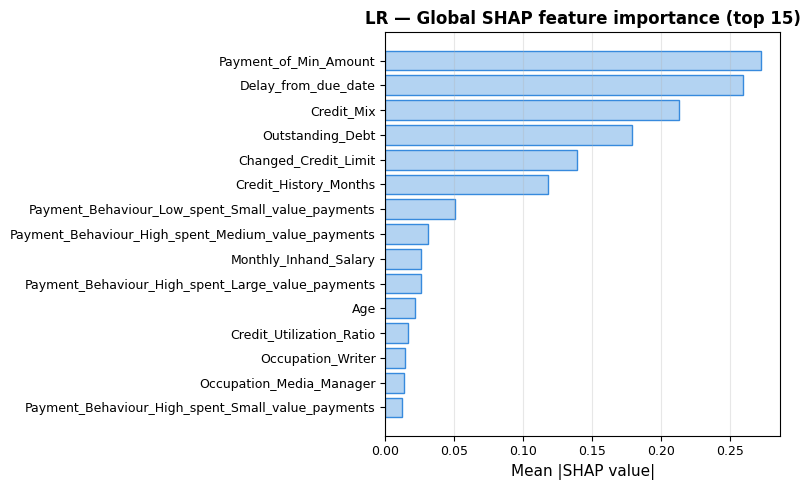

Saved → ./lr_shap_beeswarm_poor.png


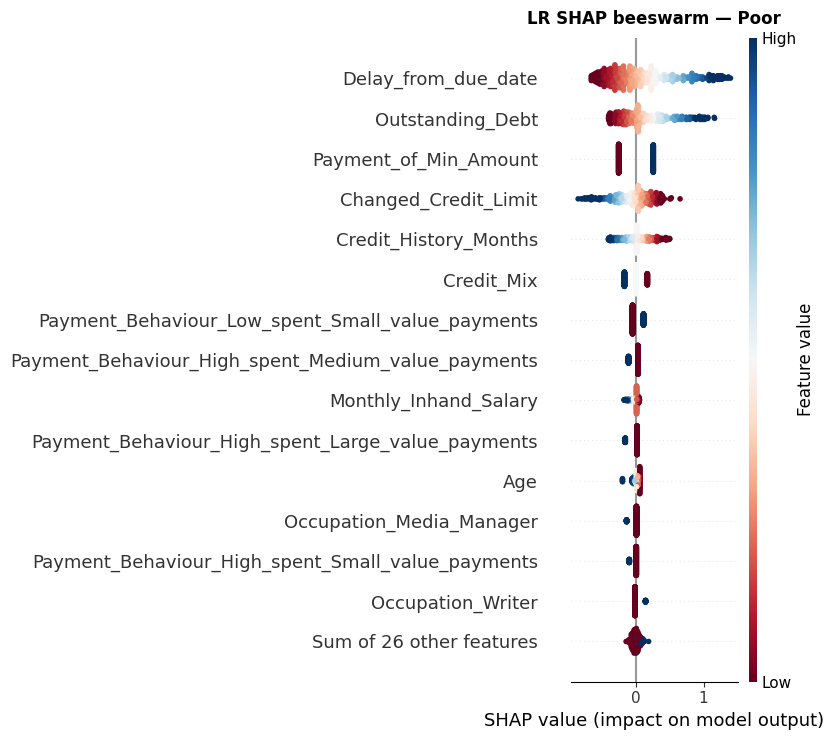

Saved → ./lr_shap_beeswarm_standard.png


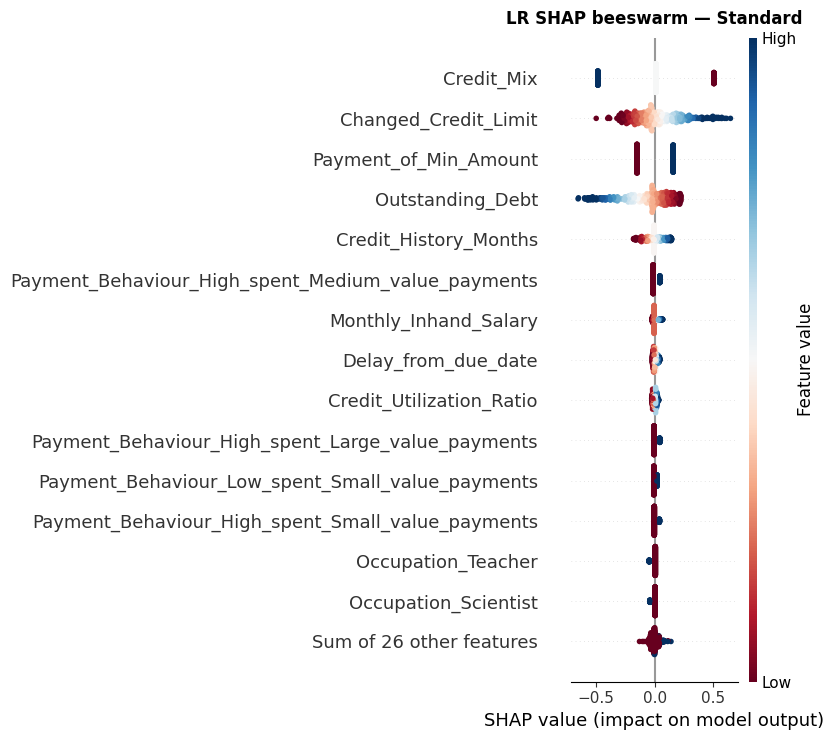

Saved → ./lr_shap_beeswarm_good.png


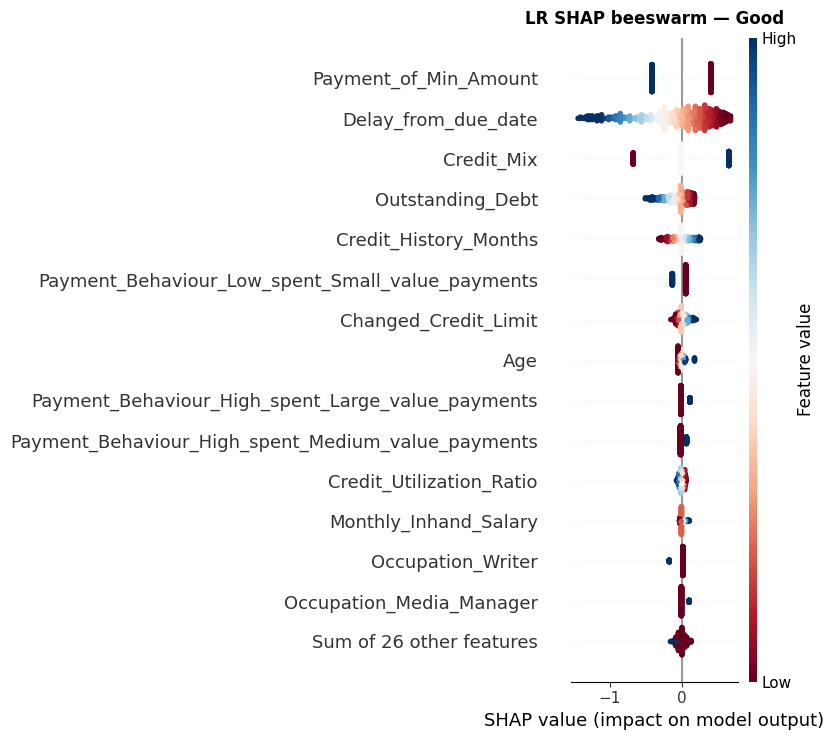


Waterfall Poor: Poor=0.919 | Std=0.080 | Good=0.001
Saved → ./lr_shap_waterfall_poor.png


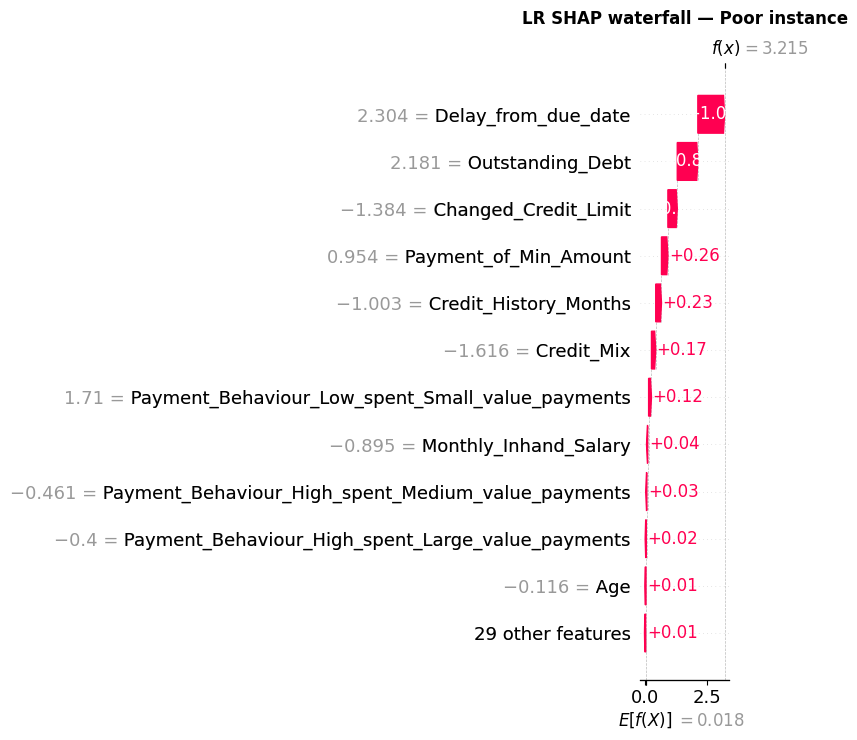


Waterfall Standard: Poor=0.088 | Std=0.872 | Good=0.040
Saved → ./lr_shap_waterfall_standard.png


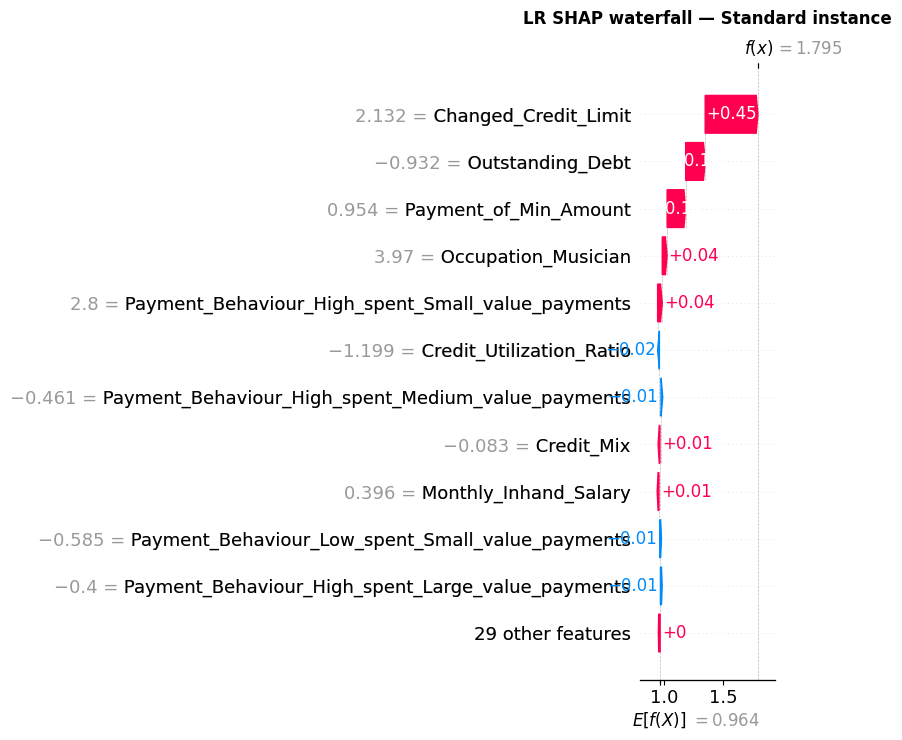


Waterfall Good: Poor=0.051 | Std=0.291 | Good=0.658
Saved → ./lr_shap_waterfall_good.png


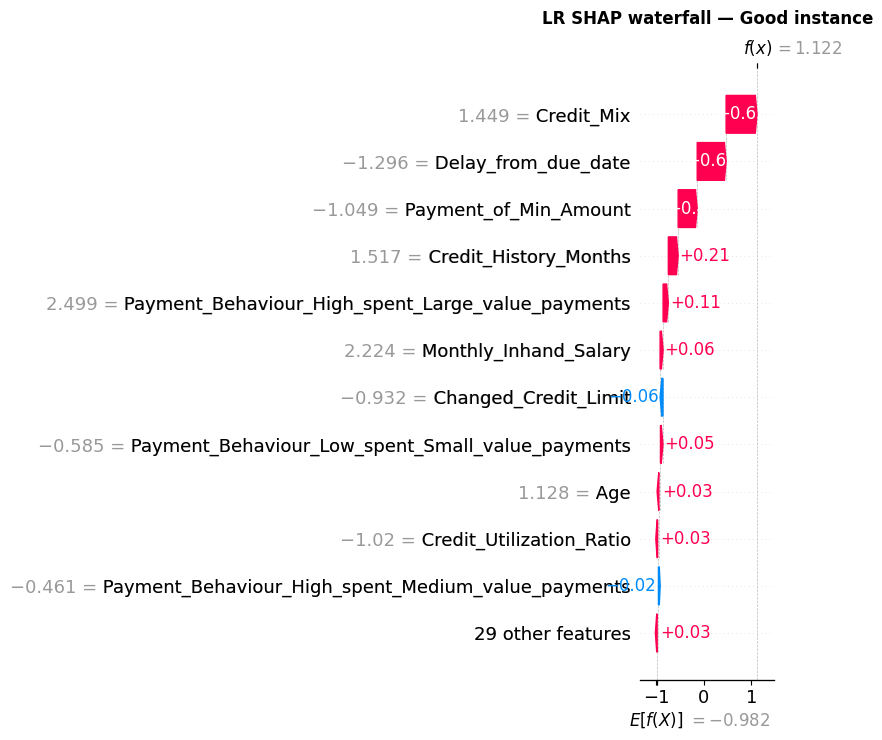

Saved → ./lr_shap_summary.png


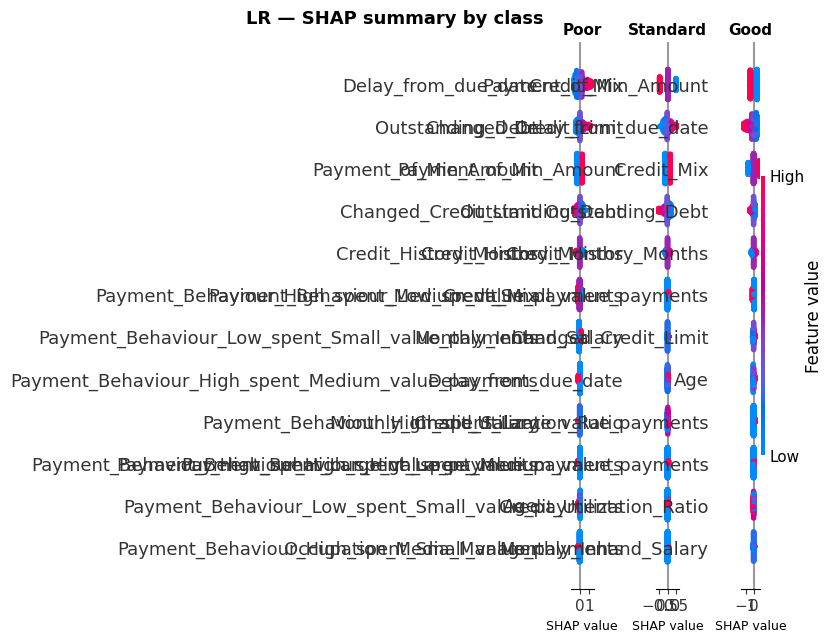


=== GLOBAL SHAP IMPORTANCE (top 10) ===
Payment_of_Min_Amount                                 0.2726
Delay_from_due_date                                   0.2597
Credit_Mix                                            0.2132
Outstanding_Debt                                      0.1786
Changed_Credit_Limit                                  0.1391
Credit_History_Months                                 0.1177
Payment_Behaviour_Low_spent_Small_value_payments      0.0505
Payment_Behaviour_High_spent_Medium_value_payments    0.0312
Monthly_Inhand_Salary                                 0.0256
Payment_Behaviour_High_spent_Large_value_payments     0.0255

=== Poor — |SHAP| top 10 ===
Delay_from_due_date                                   0.3775
Outstanding_Debt                                      0.2680
Payment_of_Min_Amount                                 0.2546
Changed_Credit_Limit                                  0.2086
Credit_History_Months                                 0.1765
Credit_Mix    

In [ ]:
# ============================================================
# SHAP ANALYSIS — Logistic Regression
# Paste this after your LR training cell.
# Requires: lr, X_tr_sc, X_te_sc, y_test, feature_names
#
# Produces and saves:
#   lr_shap_bar.png          — global bar chart
#   lr_shap_beeswarm_poor/standard/good.png
#   lr_shap_waterfall_poor/standard/good.png
#   lr_shap_summary.png      — all 3 classes side by side
# ============================================================

# pip install shap matplotlib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings("ignore")

CLASS_NAMES = ["Poor", "Standard", "Good"]
SAVE_DIR    = "."          # change to your preferred folder e.g. "shap_plots"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Sample ────────────────────────────────────────────────────
np.random.seed(42)
idx      = np.random.choice(len(X_te_sc), 500, replace=False)
X_sample = X_te_sc[idx]
y_sample = y_test.values[idx] if hasattr(y_test, "values") else y_test[idx]

# ── LinearExplainer ────────────────────────────────────────────
# LinearExplainer is exact for linear models (no approximation)
# It decomposes each prediction into: base_value + sum(feature * coef * scale)
explainer = shap.LinearExplainer(lr, X_tr_sc)
sv        = explainer.shap_values(X_sample)   # shape: (500, n_features, 3)
print(f"SHAP values shape: {sv.shape}")
print(f"Classes: 0=Poor | 1=Standard | 2=Good")

# Build shap.Explanation objects (needed for beeswarm/waterfall)
exps = []
for i in range(3):
    e = shap.Explanation(
        values      = sv[:, :, i],
        base_values = np.full(len(X_sample), explainer.expected_value[i]),
        data        = X_sample,
        feature_names = feature_names,
    )
    exps.append(e)


# ── Helper: save + show in notebook ───────────────────────────
def save_fig(fname, dpi=150):
    path = os.path.join(SAVE_DIR, fname)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved → {path}")
    plt.show()
    plt.close()


# ── 1. Global bar chart ────────────────────────────────────────
# Mean absolute SHAP averaged across all classes and instances.
# Shows overall feature reliance — model-level, not class-specific.

gimp = pd.Series(
    np.abs(sv).mean(axis=(0, 2)),
    index=feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(gimp.index[:15][::-1], gimp.values[:15][::-1],
        color="#378ADD60", edgecolor="#378ADD", linewidth=1)
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_title("LR — Global SHAP feature importance (top 15)",
             fontsize=12, fontweight="bold")
ax.tick_params(labelsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_fig("lr_shap_bar.png")


# ── 2. Beeswarm plots (one per class) ─────────────────────────
# Each dot = one instance. X-axis = SHAP value (how much this
# feature pushed the prediction toward/away from this class).
# Colour = feature value (red=high, blue=low).
# Spread on Y = density. Wide spread = many instances with that value.

for i, cls in enumerate(CLASS_NAMES):
    fig, ax = plt.subplots(figsize=(8, 6))
    shap.plots.beeswarm(exps[i], max_display=15, show=False,
                        color=plt.cm.RdBu)
    plt.title(f"LR SHAP beeswarm — {cls}",
              fontsize=12, fontweight="bold", pad=10)
    plt.tight_layout()
    save_fig(f"lr_shap_beeswarm_{cls.lower()}.png")


# ── 3. Waterfall plots (one per class) ────────────────────────
# Shows one instance: how each feature pushes the prediction
# from the base rate (average prediction) to the final output.
# Red bars = push toward this class. Blue = push away.
# Picks the most confidently predicted instance per class.

for i, cls in enumerate(CLASS_NAMES):
    cls_idx     = np.where(y_sample == i)[0]
    probs       = lr.predict_proba(X_sample[cls_idx])
    best_local  = np.argmax(probs[:, i])
    best_idx    = cls_idx[best_local]

    instance_probs = lr.predict_proba(X_sample[[best_idx]])[0]
    print(f"\nWaterfall {cls}: Poor={instance_probs[0]:.3f} | "
          f"Std={instance_probs[1]:.3f} | Good={instance_probs[2]:.3f}")

    e_inst = shap.Explanation(
        values      = sv[best_idx, :, i],
        base_values = explainer.expected_value[i],
        data        = X_sample[best_idx],
        feature_names = feature_names,
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    shap.plots.waterfall(e_inst, max_display=12, show=False)
    plt.title(f"LR SHAP waterfall — {cls} instance",
              fontsize=12, fontweight="bold", pad=10)
    plt.tight_layout()
    save_fig(f"lr_shap_waterfall_{cls.lower()}.png")


# ── 4. Summary dot plot (all 3 classes side by side) ──────────
# Like a beeswarm but shows raw SHAP values (positive/negative).
# Useful for seeing directionality across features.

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
for i, cls in enumerate(CLASS_NAMES):
    plt.sca(axes[i])
    shap.summary_plot(
        sv[:, :, i], X_sample,
        feature_names=feature_names,
        max_display=12, show=False,
        plot_type="dot", color_bar=(i == 2)
    )
    axes[i].set_title(cls, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("SHAP value", fontsize=9)

plt.suptitle("LR — SHAP summary by class",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("lr_shap_summary.png")


# ── 5. Print top features per class ────────────────────────────
print("\n=== GLOBAL SHAP IMPORTANCE (top 10) ===")
print(gimp.head(10).round(4).to_string())

for i, cls in enumerate(CLASS_NAMES):
    imp    = pd.Series(np.abs(sv[:,:,i]).mean(axis=0), index=feature_names).sort_values(ascending=False)
    signed = pd.Series(sv[:,:,i].mean(axis=0), index=feature_names)
    signed = signed.reindex(signed.abs().sort_values(ascending=False).index)
    print(f"\n=== {cls} — |SHAP| top 10 ===")
    print(imp.head(10).round(4).to_string())
    print(f"\n=== {cls} — signed direction top 10 ===")
    print(signed.head(10).round(4).to_string())

print(f"\nAll plots saved to: {os.path.abspath(SAVE_DIR)}/")

LIME explainer ready.

=== INDIVIDUAL INSTANCE EXPLANATIONS ===

--- Poor | Poor=0.919 Std=0.080 Good=0.001 ---
  Outstanding_Debt > 0.54                            +0.2394
  Delay_from_due_date > 0.54                         +0.2160
  Changed_Credit_Limit <= -0.69                      +0.1353
  Credit_History_Months <= -0.70                     +0.0970
  Credit_Mix <= -0.08                                -0.0488
  -0.58 < Payment_Behaviour_Low_spent_Small_value_payments <= 1.71 +0.0387
  Monthly_Inhand_Salary <= -0.71                     +0.0350
  Occupation_Entrepreneur <= -0.26                   -0.0336
  Occupation_Engineer <= -0.27                       -0.0319
  Occupation_Doctor <= -0.25                         +0.0309
  Occupation_Musician <= -0.25                       -0.0303
  -1.05 < Payment_of_Min_Amount <= 0.95              +0.0284
Saved → ./lr_lime_instance_poor.png


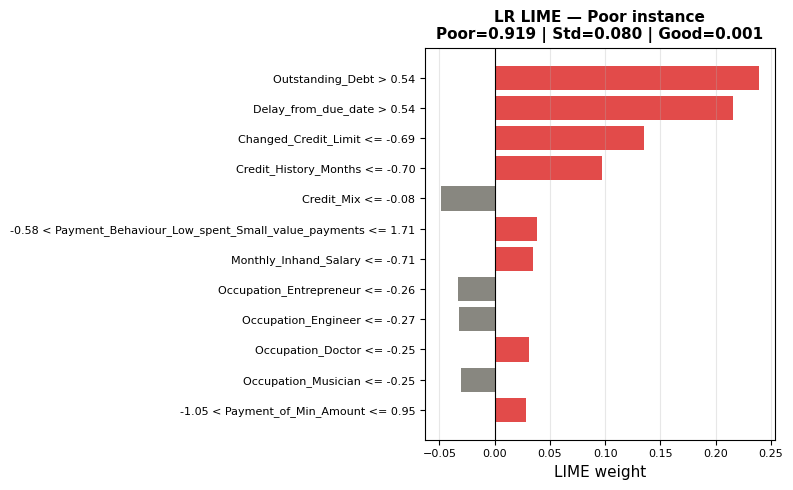


--- Standard | Poor=0.088 Std=0.872 Good=0.040 ---
  Credit_Mix <= -0.08                                +0.1616
  Changed_Credit_Limit > 0.59                        +0.1458
  Outstanding_Debt <= -0.65                          +0.1199
  Occupation_Media_Manager <= -0.26                  +0.0509
  Occupation_Teacher <= -0.26                        +0.0501
  Occupation_Entrepreneur <= -0.26                   +0.0494
  Payment_Behaviour_Low_spent_Medium_value_payments <= -0.40 +0.0442
  Occupation_Developer <= -0.26                      +0.0366
  Payment_Behaviour_High_spent_Medium_value_payments <= -0.46 -0.0360
  Payment_Behaviour_High_spent_Large_value_payments <= -0.40 -0.0342
  Occupation_Accountant <= -0.25                     +0.0327
  Occupation_Architect <= -0.26                      -0.0255
Saved → ./lr_lime_instance_standard.png


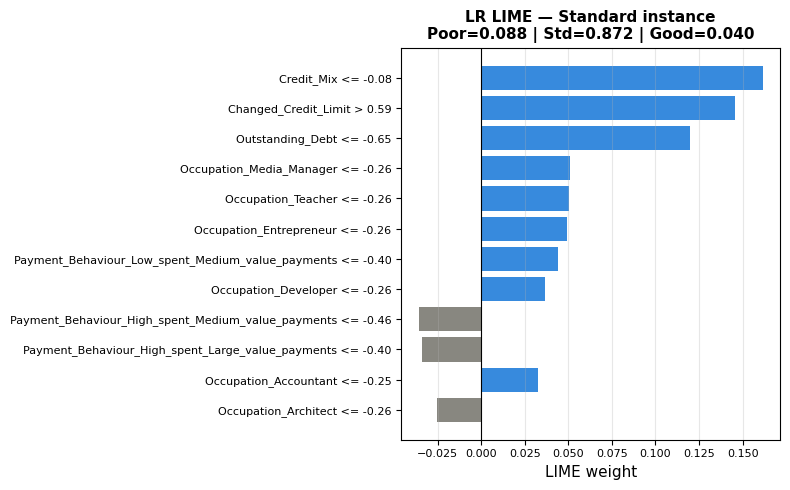


--- Good | Poor=0.051 Std=0.291 Good=0.658 ---
  -0.08 < Credit_Mix <= 1.45                         +0.1296
  Delay_from_due_date <= -0.69                       +0.0650
  Payment_of_Min_Amount <= -1.05                     +0.0424
  Credit_History_Months > 0.68                       +0.0298
  Occupation_Journalist <= -0.26                     -0.0278
  Age > 0.40                                         +0.0197
  Monthly_Inhand_Salary > 0.63                       +0.0156
  Occupation_Lawyer > -0.26                          +0.0147
  Occupation_Writer <= -0.25                         +0.0139
  Payment_Behaviour_High_spent_Large_value_payments > -0.40 +0.0139
  Payment_Behaviour_Low_spent_Small_value_payments <= -0.58 +0.0126
  Occupation_Scientist <= -0.26                      -0.0111
Saved → ./lr_lime_instance_good.png


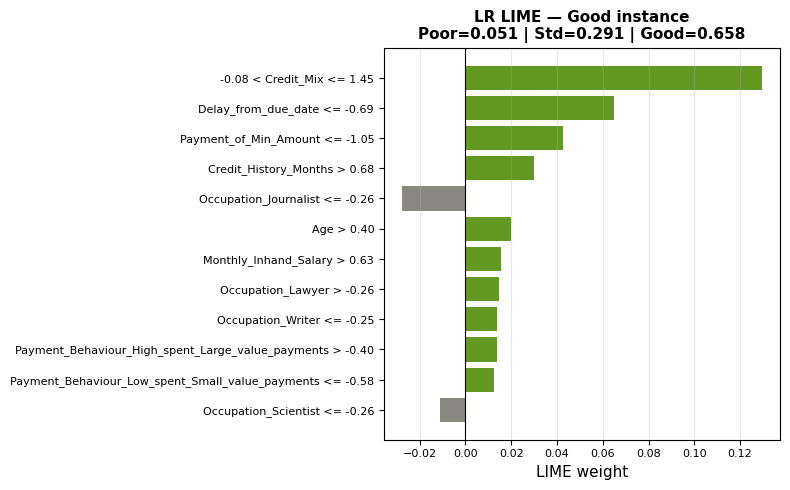


=== AGGREGATED LIME (50 instances per class) ===
  Running Poor (50 instances)...
  Running Standard (50 instances)...
  Running Good (50 instances)...

Poor — top 12:
  Outstanding_Debt                                   0.1928
  Delay_from_due_date                                0.1626
  Changed_Credit_Limit                               0.1225
  Credit_History_Months                              0.0911
  Occupation_Scientist                               0.0598
  Occupation_Musician                                0.0579
  Occupation_Teacher                                 0.0570
  Occupation_Manager                                 0.0557
  Occupation_Engineer                                0.0551
  Occupation_Media_Manager                           0.0546
  Payment_Behaviour_High_spent_Large_value_payments  0.0529
  Payment_Behaviour_Low_spent_Large_value_payments   0.0525

Standard — top 12:
  Credit_Mix                                         0.1608
  Outstanding_Debt             

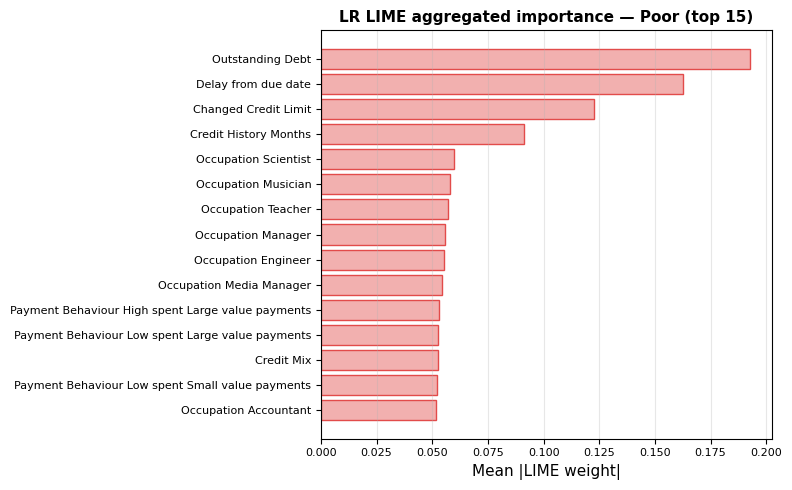

Saved → ./lr_lime_agg_standard.png


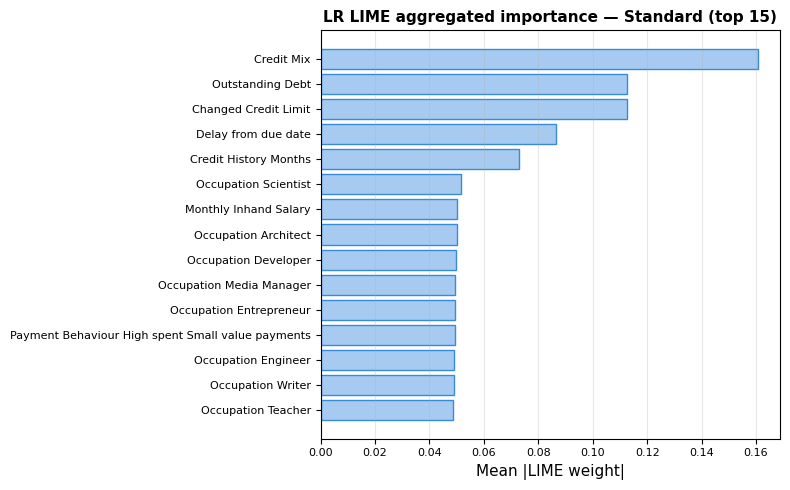

Saved → ./lr_lime_agg_good.png


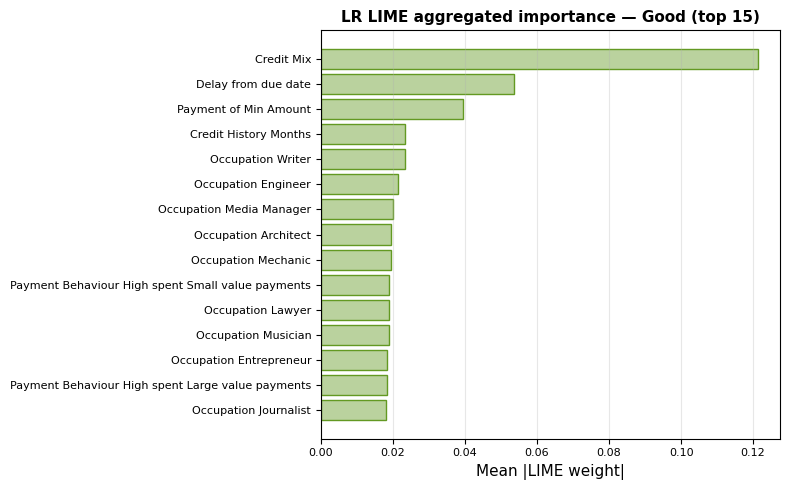


All plots saved to: /content/


In [ ]:
# ============================================================
# LIME ANALYSIS — Logistic Regression
# Paste this after your LR training cell.
# Requires: lr, X_tr_sc, X_te_sc, y_test_lr, feature_names_lr
#
# Produces and saves:
#   lr_lime_agg_poor.png
#   lr_lime_agg_standard.png
#   lr_lime_agg_good.png
#   lr_lime_instance_poor.png
#   lr_lime_instance_standard.png
#   lr_lime_instance_good.png
# ============================================================

# pip install lime matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings("ignore")

from lime.lime_tabular import LimeTabularExplainer

CLASS_NAMES = ["Poor", "Standard", "Good"]
CLS_COLS    = ["#E24B4A", "#378ADD", "#639922"]
SAVE_DIR    = "."   # change to your preferred folder
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Sample ─────────────────────────────────────────────────────
np.random.seed(42)
idx      = np.random.choice(len(X_te_sc), 500, replace=False)
X_sample = X_te_sc[idx]
y_sample = y_test_lr.values[idx] if hasattr(y_test_lr, "values") else y_test_lr[idx]

# ── Build explainer ────────────────────────────────────────────
# Note: X_sample is in scaled space (StandardScaler applied).
# LIME rules will show scaled thresholds — e.g. "Outstanding_Debt > 0.54"
# means the scaled value. To convert back to original units you would
# need to apply scaler.inverse_transform(). For thesis reporting,
# note this limitation: LR LIME rules are in standardised feature space
# unlike XGBoost LIME which operates on raw feature values.
explainer = LimeTabularExplainer(
    X_sample,
    feature_names=feature_names_lr,
    class_names=CLASS_NAMES,
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)
print("LIME explainer ready.")

# ─────────────────────────────────────────────
# 1. INDIVIDUAL INSTANCE EXPLANATIONS
#    Most confidently predicted instance per class
# ─────────────────────────────────────────────
print("\n=== INDIVIDUAL INSTANCE EXPLANATIONS ===")

def save_fig(fname, dpi=150):
    path = os.path.join(SAVE_DIR, fname)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved → {path}")
    plt.show()
    plt.close()

for tc, cls in enumerate(CLASS_NAMES):
    cls_idx    = np.where(y_sample == tc)[0]
    probs      = lr.predict_proba(X_sample[cls_idx])
    best_local = np.argmax(probs[:, tc])
    best_idx   = cls_idx[best_local]
    inst_probs = lr.predict_proba(X_sample[[best_idx]])[0]

    print(f"\n--- {cls} | Poor={inst_probs[0]:.3f} Std={inst_probs[1]:.3f} Good={inst_probs[2]:.3f} ---")

    exp = explainer.explain_instance(
        X_sample[best_idx], lr.predict_proba,
        num_features=12, num_samples=500, top_labels=3
    )

    rules = exp.as_list(label=tc)
    for rule, weight in rules:
        print(f"  {rule:<50} {weight:+.4f}")

    # Plot
    feats   = [r[0] for r in rules]
    weights = [r[1] for r in rules]
    colors  = [CLS_COLS[tc] if w > 0 else "#888780" for w in weights]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(feats[::-1], weights[::-1], color=colors[::-1], edgecolor="none")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("LIME weight", fontsize=11)
    ax.set_title(f"LR LIME — {cls} instance\n"
                 f"Poor={inst_probs[0]:.3f} | Std={inst_probs[1]:.3f} | Good={inst_probs[2]:.3f}",
                 fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    save_fig(f"lr_lime_instance_{cls.lower()}.png")


# ─────────────────────────────────────────────
# 2. AGGREGATED LIME (50 instances per class)
#    Averages |weight| across instances to get
#    a pseudo-global LIME importance ranking.
# ─────────────────────────────────────────────
print("\n=== AGGREGATED LIME (50 instances per class) ===")
cfw = {0: {}, 1: {}, 2: {}}

for tc, cls in enumerate(CLASS_NAMES):
    cls_idx = np.where(y_sample == tc)[0][:50]
    print(f"  Running {cls} ({len(cls_idx)} instances)...")
    for i in cls_idx:
        exp = explainer.explain_instance(
            X_sample[i], lr.predict_proba,
            num_features=12, num_samples=300, top_labels=3
        )
        if tc in exp.as_map():
            for fi, w in exp.as_map()[tc]:
                cfw[tc].setdefault(feature_names_lr[fi], []).append(abs(w))

agg_results = {}
for cls in range(3):
    agg = {k: np.mean(v) for k, v in cfw[cls].items() if len(v) >= 5}
    agg_results[cls] = sorted(agg.items(), key=lambda x: x[1], reverse=True)

# Print top 12 per class
for cls in range(3):
    print(f"\n{CLASS_NAMES[cls]} — top 12:")
    for feat, w in agg_results[cls][:12]:
        print(f"  {feat:<50} {w:.4f}")

# Plot aggregated bar charts
for cls in range(3):
    top = agg_results[cls][:15]
    feats  = [f[0].replace("_", " ") for f in top][::-1]
    values = [f[1] for f in top][::-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(feats, values, color=f"{CLS_COLS[cls]}70",
            edgecolor=CLS_COLS[cls], linewidth=1)
    ax.set_xlabel("Mean |LIME weight|", fontsize=11)
    ax.set_title(f"LR LIME aggregated importance — {CLASS_NAMES[cls]} (top 15)",
                 fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    save_fig(f"lr_lime_agg_{CLASS_NAMES[cls].lower()}.png")


# ─────────────────────────────────────────────
# 3. SHAP vs LIME AGREEMENT
#    Requires shap_values sv from lr_shap_notebook.py
#    Uncomment if sv is in scope
# ─────────────────────────────────────────────
# print("\n=== SHAP vs LIME AGREEMENT ===")
# for cls in range(3):
#     shap_imp = pd.Series(np.abs(sv[:,:,cls]).mean(axis=0),
#                          index=feature_names_lr).sort_values(ascending=False)
#     shap_top = shap_imp.head(10).index.tolist()
#     lime_top = [f for f,_ in agg_results[cls][:10]]
#     agree    = sum(1 for f in shap_top if f in lime_top)
#     print(f"  {CLASS_NAMES[cls]}: {agree}/10 features agree")
#     print(f"    SHAP top 5: {shap_top[:5]}")
#     print(f"    LIME top 5: {lime_top[:5]}")

print(f"\nAll plots saved to: {os.path.abspath(SAVE_DIR)}/")

Computed: Outstanding_Debt | Poor [0.173, 0.539]
Computed: Interest_Rate | Poor [0.294, 0.294]
Computed: Credit_Mix | Poor [0.274, 0.327]
Computed: Delay_from_due_date | Poor [0.186, 0.532]
Computed: Num_Credit_Card | Poor [0.294, 0.294]
Computed: Credit_History_Months | Poor [0.204, 0.380]
Computed: Payment_of_Min_Amount | Poor [0.267, 0.331]
Computed: Changed_Credit_Limit | Poor [0.182, 0.409]
Computed: Total_EMI_per_month | Poor [0.294, 0.294]
Computed: Monthly_Balance | Poor [0.238, 0.295]

Saved → ./lr_pdp_plots.png


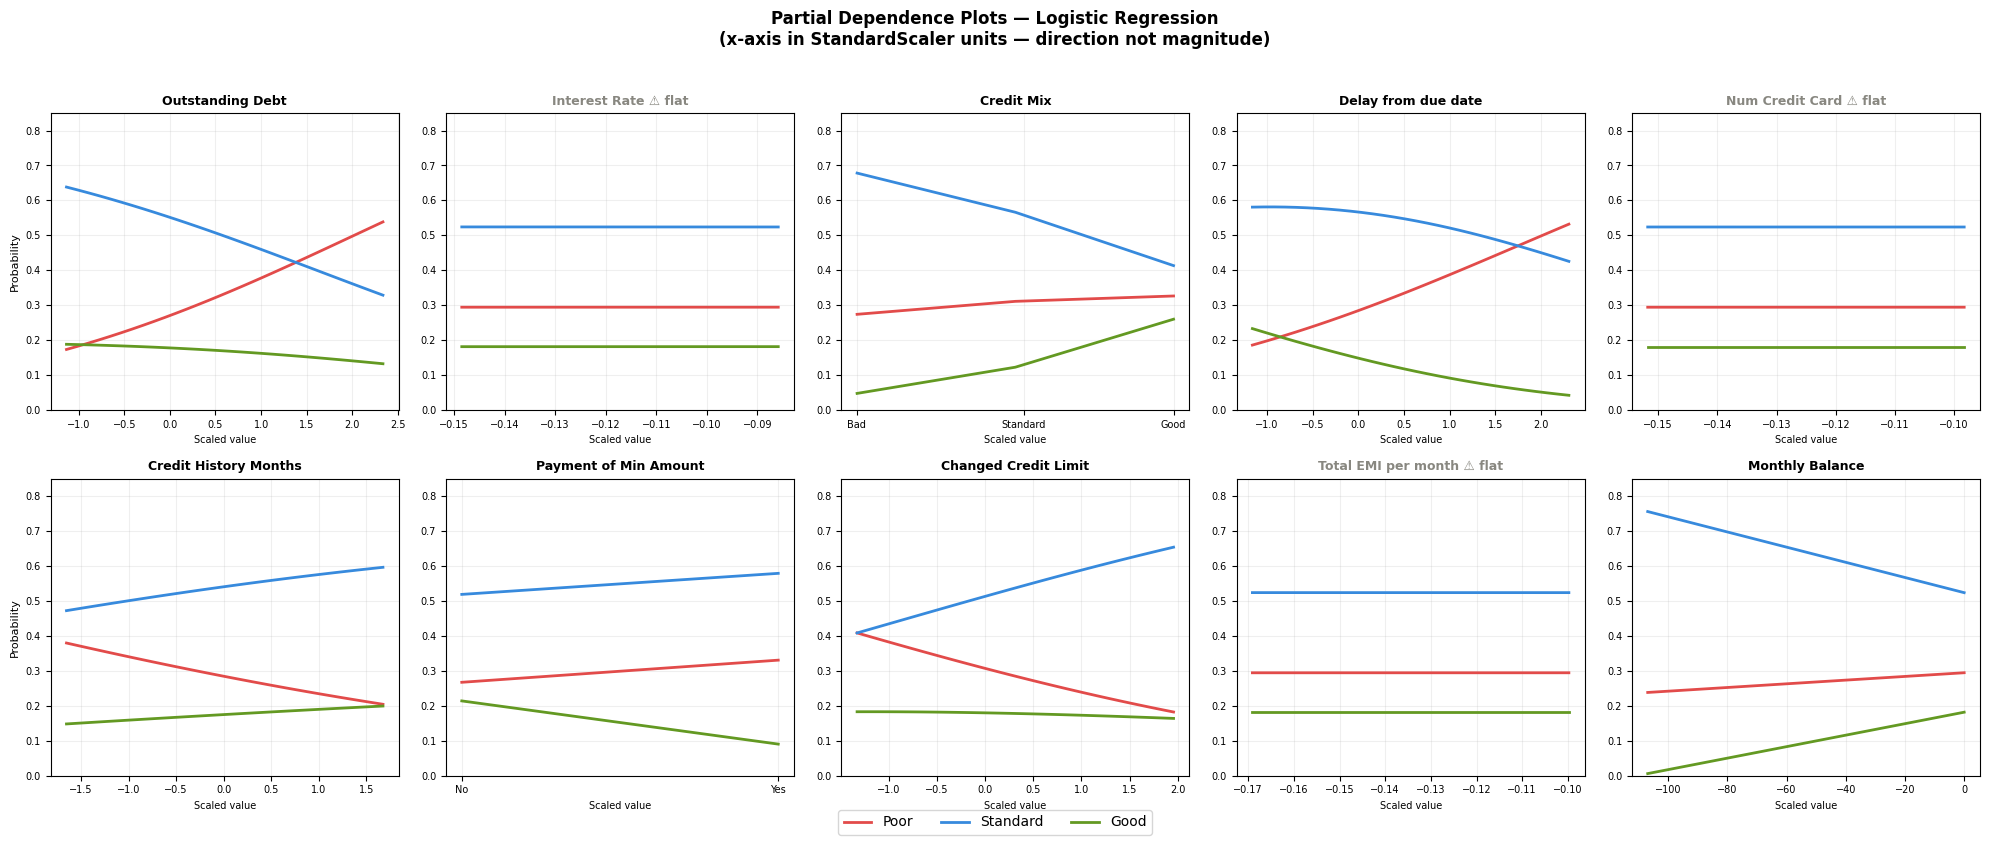


=== PDP OBSERVATIONS ===
Flat (no effect): Interest_Rate, Num_Credit_Card, Total_EMI_per_month
  → Scaled values in test set fall in a narrow band — no marginal effect visible
  → Does NOT mean feature is unimportant — SHAP still assigns it signal
Strongest effects: Delay_from_due_date, Outstanding_Debt, Changed_Credit_Limit
  → All monotonic linear — consistent with LR's linear structure
Key finding: Payment_of_Min_Amount=Yes increases Poor (0.268→0.330)
  → Minimum payers are Standard/Poor, not Good — matches SHAP direction


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings("ignore")

from sklearn.inspection import partial_dependence

SAVE_DIR = "."
os.makedirs(SAVE_DIR, exist_ok=True)

TOP_FEATURES = [
    'Outstanding_Debt', 'Interest_Rate', 'Credit_Mix',
    'Delay_from_due_date', 'Num_Credit_Card', 'Credit_History_Months',
    'Payment_of_Min_Amount', 'Changed_Credit_Limit',
    'Total_EMI_per_month', 'Monthly_Balance'
]
CLASS_NAMES = ['Poor', 'Standard', 'Good']
CLS_COLS    = ['#E24B4A', '#378ADD', '#639922']

feat_idx = [feature_names_lr.index(f) for f in TOP_FEATURES]

# Subsample for speed
np.random.seed(42)
Xs = X_te_sc[np.random.choice(len(X_te_sc), 2000, replace=False)]

# ── Compute PDPs ──────────────────────────────────────────────
pdp_results = {}
for fname, fi in zip(TOP_FEATURES, feat_idx):
    res = partial_dependence(lr, Xs, features=[fi],
                             kind='average', grid_resolution=30)
    pdp_results[fname] = {
        'grid':     res['grid_values'][0],
        'poor':     res['average'][0],
        'standard': res['average'][1],
        'good':     res['average'][2],
    }
    print(f"Computed: {fname} | "
          f"Poor [{res['average'][0].min():.3f}, {res['average'][0].max():.3f}]")

# ── Plot 2 × 5 grid ───────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, fname in enumerate(TOP_FEATURES):
    ax  = axes[i]
    d   = pdp_results[fname]
    g   = d['grid']

    # Detect flat features (near-zero range)
    flat = (d['poor'].max() - d['poor'].min()) < 0.005

    for cls, col in zip(CLASS_NAMES, CLS_COLS):
        ax.plot(g, d[cls.lower()], color=col, linewidth=2, label=cls)

    title = fname.replace('_', ' ')
    if flat:
        title += ' ⚠ flat'
    ax.set_title(title, fontsize=9, fontweight='bold',
                 color='#888780' if flat else 'black') # Changed None to 'black'
    ax.set_xlabel('Scaled value', fontsize=7)
    ax.set_ylabel('Probability' if i % 5 == 0 else '', fontsize=8)
    ax.set_ylim(0, 0.85)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

    # Label categorical features
    if fname == 'Credit_Mix':
        ax.set_xticks([-1.62, 0.0, 1.45])
        ax.set_xticklabels(['Bad', 'Standard', 'Good'], fontsize=7)
    elif fname == 'Payment_of_Min_Amount':
        ax.set_xticks([-1.05, 0.95])
        ax.set_xticklabels(['No', 'Yes'], fontsize=7)

# Shared legend
handles = [plt.Line2D([0],[0], color=c, linewidth=2, label=n)
           for c, n in zip(CLS_COLS, CLASS_NAMES)]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Partial Dependence Plots — Logistic Regression\n'
             '(x-axis in StandardScaler units — direction not magnitude)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

path = os.path.join(SAVE_DIR, 'lr_pdp_plots.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
print(f"\nSaved → {path}")
plt.show()
plt.close()

# ── Key observations ──────────────────────────────────────────
print("\n=== PDP OBSERVATIONS ===")
print("Flat (no effect): Interest_Rate, Num_Credit_Card, Total_EMI_per_month")
print("  → Scaled values in test set fall in a narrow band — no marginal effect visible")
print("  → Does NOT mean feature is unimportant — SHAP still assigns it signal")
print("Strongest effects: Delay_from_due_date, Outstanding_Debt, Changed_Credit_Limit")
print("  → All monotonic linear — consistent with LR's linear structure")
print("Key finding: Payment_of_Min_Amount=Yes increases Poor (0.268→0.330)")
print("  → Minimum payers are Standard/Poor, not Good — matches SHAP direction")